In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_scope import get_connection, load_orders_clean, load_order_items_clean

conn = get_connection()
orders = load_orders_clean(conn)
items = load_order_items_clean(conn)

In [2]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders["order_week"] = orders["order_purchase_timestamp"].dt.to_period("W")
orders["order_weekday"] = orders["order_purchase_timestamp"].dt.dayofweek


In [3]:
df = items.merge(
    orders[["order_id", "order_month", "order_week", "order_weekday"]],
    on="order_id",
    how="left"
)


### Observation – Time Granularity

Monthly GMV appears smoother and more stable, while weekly GMV is more volatile.
Monthly aggregation will be used for further analysis.


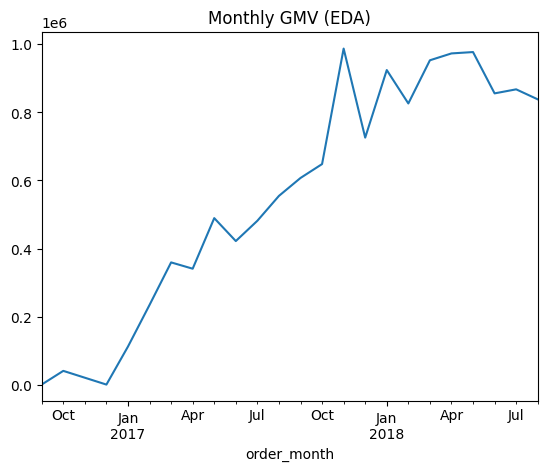

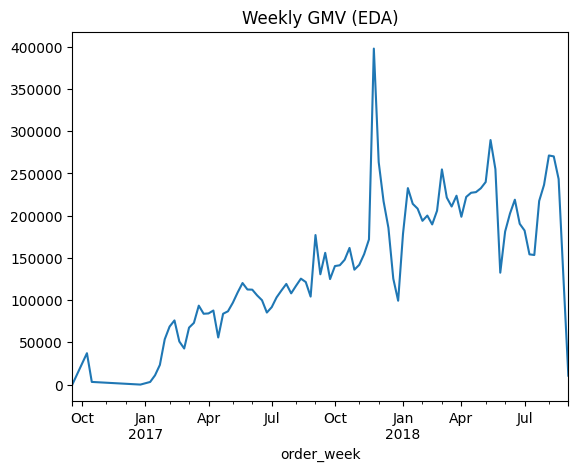

In [4]:
monthly_gmv = df.groupby("order_month")["price"].sum()
weekly_gmv = df.groupby("order_week")["price"].sum()

plt.figure()
monthly_gmv.plot(title="Monthly GMV (EDA)")
plt.show()

plt.figure()
weekly_gmv.plot(title="Weekly GMV (EDA)")
plt.show()


In [5]:
monthly = df.groupby("order_month").agg({
    "price": "sum",
    "order_id": "nunique"
}).rename(columns={
    "price": "gmv",
    "order_id": "order_count"
})

monthly["aov"] = monthly["gmv"] / monthly["order_count"]


### Observation – GMV Trend

GMV shows an overall trend with noticeable fluctuations across months.


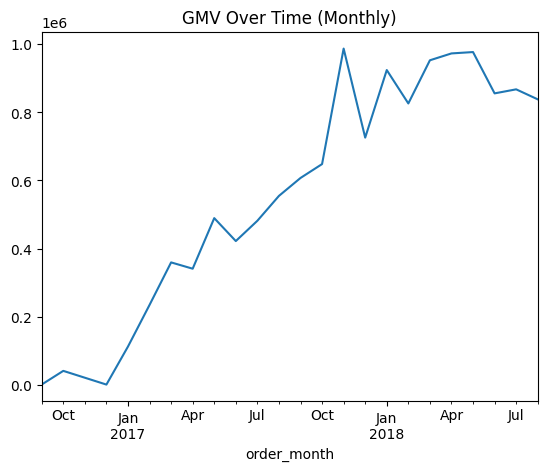

In [6]:
plt.figure()
monthly["gmv"].plot(title="GMV Over Time (Monthly)")
plt.show()


### Observation – Order Count

Order count follows a similar pattern to GMV.


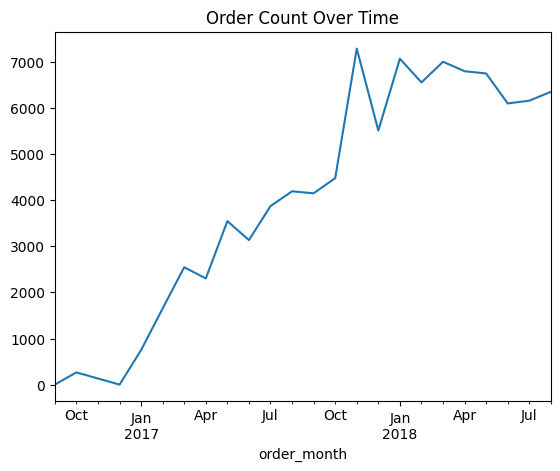

In [7]:
plt.figure()
monthly["order_count"].plot(title="Order Count Over Time")
plt.show()


### Observation – AOV

AOV appears relatively stable compared to GMV and order count.


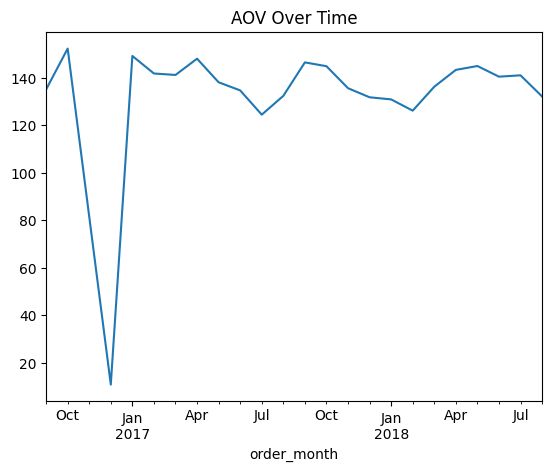

In [8]:
plt.figure()
monthly["aov"].plot(title="AOV Over Time")
plt.show()


### Observation – Monthly Distribution

Orders are unevenly distributed across months.


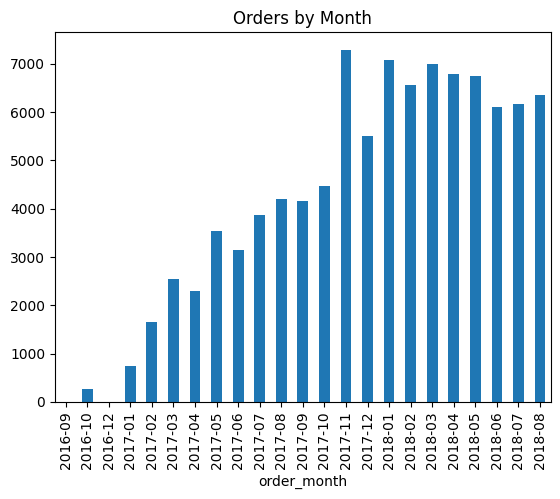

In [9]:
monthly_orders = orders["order_month"].value_counts().sort_index()

plt.figure()
monthly_orders.plot(kind="bar", title="Orders by Month")
plt.show()


### Observation – Weekly Pattern

Order distribution varies across weekdays.


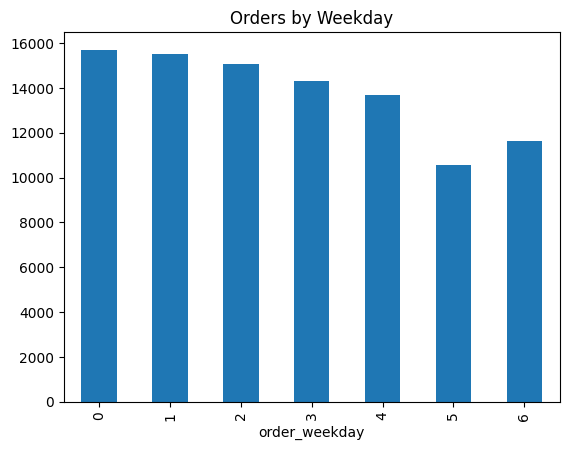

In [10]:
weekday_orders = orders["order_weekday"].value_counts().sort_index()

plt.figure()
weekday_orders.plot(kind="bar", title="Orders by Weekday")
plt.show()


In [11]:
# 转时间
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# 合并 GMV
df = items.merge(
    orders[["order_id", "customer_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

# 每个订单的 GMV
order_gmv = df.groupby("order_id")["price"].sum().reset_index()

# 合并 customer_id
order_gmv = order_gmv.merge(
    orders[["order_id", "customer_id", "order_purchase_timestamp"]],
    on="order_id"
)


### 6 Observation – Customer Distribution

Customers are concentrated in a few key states.


<Axes: title={'center': 'Top States by Customers'}, xlabel='customer_state'>

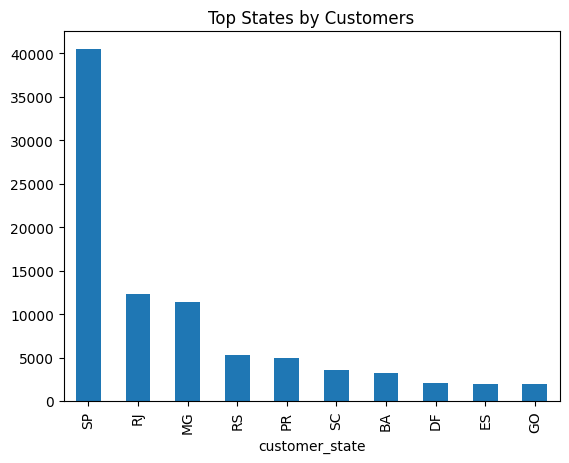

In [12]:
customers = pd.read_sql(
    "SELECT customer_id, customer_state FROM customers",
    conn
)

orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

customer_geo = orders["customer_state"].value_counts()
customer_geo.head(10).plot(kind="bar", title="Top States by Customers")



### 7 Observation – New vs Returning Customers

Both new and returning customers contribute to GMV.


In [13]:
# 1. 获取真实用户ID
customers = pd.read_sql(
    "SELECT customer_id, customer_unique_id FROM customers",
    conn
)

orders = orders.merge(customers, on="customer_id", how="left")


# 2. 每个用户首单时间（用 customer_unique_id）
first_order = orders.groupby("customer_unique_id")[
    "order_purchase_timestamp"
].min().reset_index()

first_order.columns = ["customer_unique_id", "first_order_time"]

orders = orders.merge(first_order, on="customer_unique_id", how="left")


# 3. 标记新客
orders["is_new_customer"] = (
    orders["order_purchase_timestamp"] == orders["first_order_time"]
)


# 4. 计算每个订单GMV（如果前面没做过）
order_gmv = items.groupby("order_id")["price"].sum().reset_index()


# 5. 合并新客标记
order_gmv = order_gmv.merge(
    orders[["order_id", "is_new_customer"]],
    on="order_id",
    how="left"
)


# 6. 聚合GMV
gmv_split = order_gmv.groupby("is_new_customer")["price"].sum()

gmv_split


is_new_customer
False      358348.58
True     12863149.53
Name: price, dtype: float64

### 8 Observation – Repeat Purchase Rate

A portion of customers have made more than one purchase.


In [14]:
order_counts = orders.groupby("customer_unique_id")["order_id"].nunique()

repeat_rate = (order_counts > 1).mean()

repeat_rate


np.float64(0.03000278497825575)

### 9 Observation – Time Between Purchases

There is variation in the time gap between first and second purchases.


In [15]:
# 排序
orders_sorted = orders.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
)

# 排名
orders_sorted["order_rank"] = (
    orders_sorted.groupby("customer_unique_id").cumcount() + 1
)

# 只保留前两单
first_second = orders_sorted[orders_sorted["order_rank"] <= 2]

# pivot（关键！！！）
pivot = first_second.pivot(
    index="customer_unique_id",
    columns="order_rank",
    values="order_purchase_timestamp"
)

# 去掉没有第二单的用户
pivot = pivot.dropna()

# 计算间隔
pivot["gap_days"] = (pivot[2] - pivot[1]).dt.days

# 查看结果
pivot["gap_days"].describe()




count    2801.000000
mean       80.844698
std       109.899443
min         0.000000
25%         0.000000
50%        28.000000
75%       126.000000
max       608.000000
Name: gap_days, dtype: float64

q11

<Axes: title={'center': 'Top Categories by GMV'}, xlabel='product_category_name'>

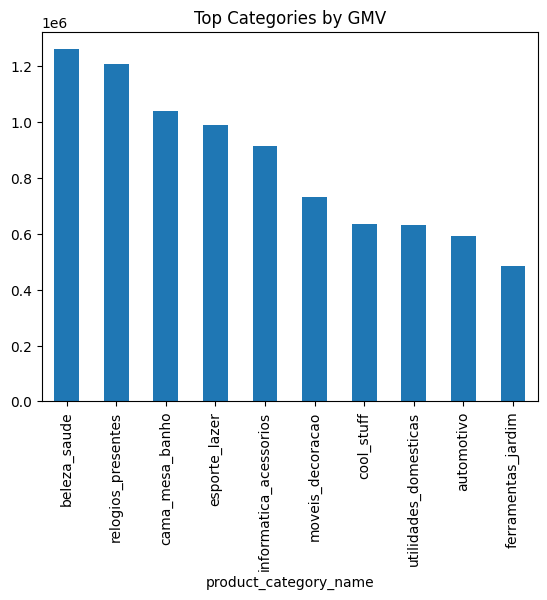

In [16]:
products = pd.read_sql(
    "SELECT product_id, product_category_name FROM products",
    conn
)

df = items.merge(products, on="product_id", how="left")

category_gmv = df.groupby("product_category_name")["price"].sum().sort_values(ascending=False)

category_gmv.head(10).plot(kind="bar", title="Top Categories by GMV")


q12

In [17]:
df = items.merge(products, on="product_id", how="left")

category_stats = df.groupby("product_category_name").agg({
    "order_id": "count",
    "price": "mean"
}).rename(columns={
    "order_id": "sales_volume",
    "price": "avg_price"
})

category_stats.sort_values("sales_volume", ascending=False).head(10)


,sales_volume,avg_price
product_category_name,,
cama_mesa_banho,11115,93.296327
beleza_saude,9670,130.163531
esporte_lazer,8641,114.344285
moveis_decoracao,8334,87.564494
informatica_acessorios,7827,116.513903
utilidades_domesticas,6964,90.788148
relogios_presentes,5991,201.135984
telefonia,4545,71.213978
ferramentas_jardim,4347,111.630196


q13

<Axes: xlabel='product_weight_g', ylabel='freight_value'>

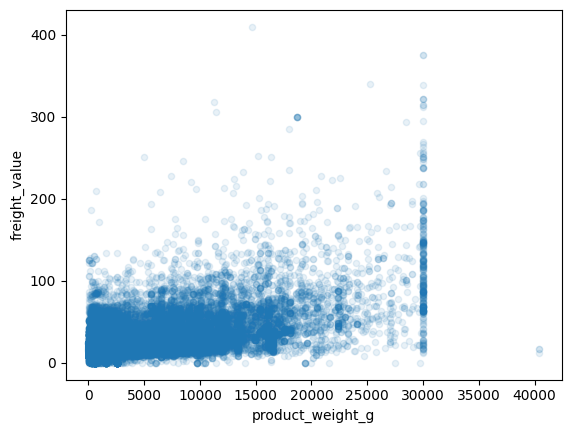

In [18]:
products = pd.read_sql(
    "SELECT product_id, product_weight_g FROM products",
    conn
)

df = items.merge(products, on="product_id", how="left")

df[["product_weight_g", "freight_value"]].corr()
df.plot.scatter(x="product_weight_g", y="freight_value", alpha=0.1)


q14

<Axes: title={'center': 'Cumulative GMV Share by Sellers'}, xlabel='seller_id'>

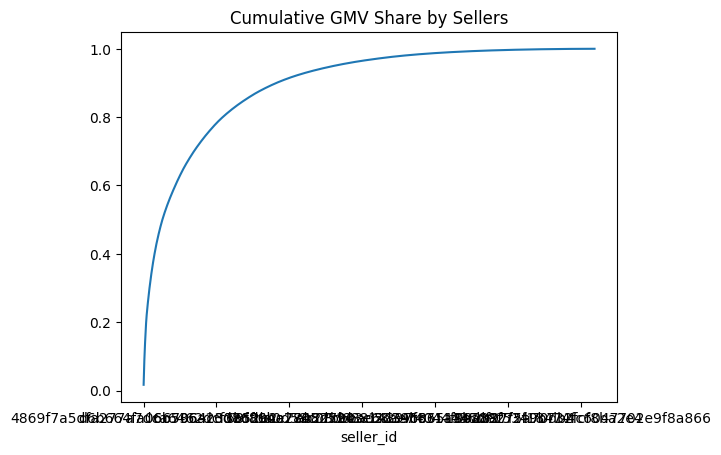

In [19]:
seller_gmv = items.groupby("seller_id")["price"].sum().sort_values(ascending=False)

seller_share = seller_gmv.cumsum() / seller_gmv.sum()

seller_share.head(20)
seller_share.plot(title="Cumulative GMV Share by Sellers")


q15

count    2970.000000
mean       11.700448
std         7.110236
min         1.000000
25%         7.937500
50%        10.685541
75%        13.811794
max       189.000000
Name: delivery_days, dtype: float64


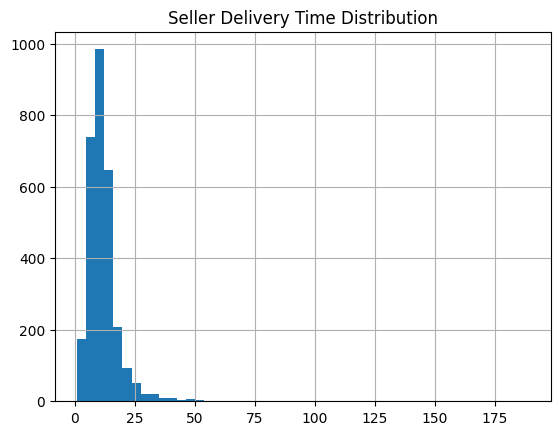

In [20]:
# Q15: Seller delivery performance (simple)
import matplotlib.pyplot as plt
# 时间处理
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

# 配送天数
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# 合并 seller
df = items.merge(
    orders[["order_id", "delivery_days"]],
    on="order_id",
    how="left"
)

# 每个卖家平均配送时间
seller_avg = df.groupby("seller_id")["delivery_days"].mean()

# 输出 + 简单图
print(seller_avg.describe())
seller_avg.hist(bins=50)
plt.title("Seller Delivery Time Distribution")
plt.show()


q16

<Axes: xlabel='delivery_days', ylabel='review_score'>

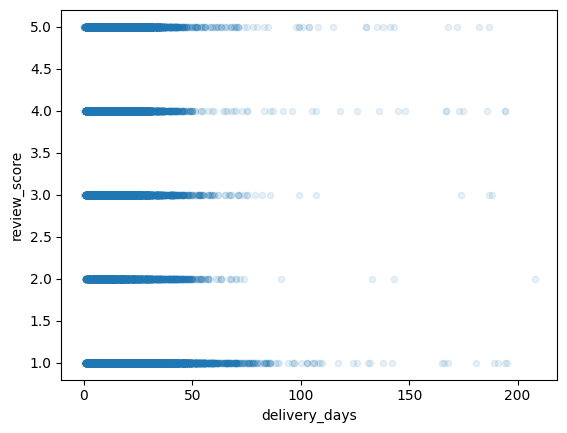

In [21]:
reviews = pd.read_sql(
    "SELECT order_id, review_score FROM order_reviews",
    conn
)

df = orders.merge(reviews, on="order_id", how="left")

df["delivery_days"] = (
    pd.to_datetime(df["order_delivered_customer_date"]) -
    pd.to_datetime(df["order_purchase_timestamp"])
).dt.days

df[["delivery_days", "review_score"]].corr()
df.plot.scatter(x="delivery_days", y="review_score", alpha=0.1)


q17

<Axes: title={'center': 'Review Score Distribution'}, xlabel='review_score'>

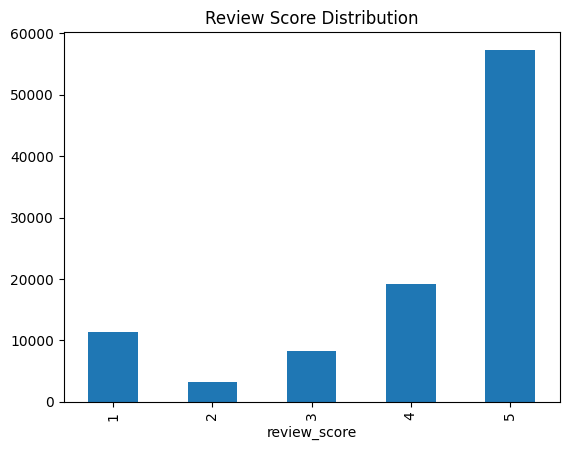

In [22]:
# Q17: Review score distribution

reviews = pd.read_sql(
    "SELECT review_score FROM order_reviews",
    conn
)

reviews["review_score"].value_counts().sort_index().plot(kind="bar", title="Review Score Distribution")


q18

In [23]:
# Q18: Factors affecting low ratings

reviews = pd.read_sql(
    "SELECT order_id, review_score FROM order_reviews",
    conn
)

payments = pd.read_sql(
    "SELECT order_id, payment_installments FROM order_payments",
    conn
)

# 时间处理
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

# 配送天数 + 是否延迟
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["is_late"] = (
    orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
)

# 运费
freight = items.groupby("order_id")["freight_value"].sum().reset_index()

# 合并
df = orders.merge(reviews, on="order_id", how="left") \
           .merge(payments, on="order_id", how="left") \
           .merge(freight, on="order_id", how="left")

# 低评分标记
df["low_score"] = df["review_score"] <= 2

# 简单对比
print(df.groupby("is_late")["low_score"].mean())
print(df.groupby("payment_installments")["low_score"].mean().head())
print(df.groupby(pd.qcut(df["freight_value"], 4))["low_score"].mean())


is_late
False    0.092464
True     0.529945
Name: low_score, dtype: float64
payment_installments
0.0    0.000000
1.0    0.120039
2.0    0.121532
3.0    0.135061
4.0    0.131275
Name: low_score, dtype: float64
freight_value
(-0.001, 13.86]     0.091611
(13.86, 17.2]       0.118116
(17.2, 24.05]       0.120112
(24.05, 1794.96]    0.181121
Name: low_score, dtype: float64


C:\Users\wh\AppData\Local\Temp\ipykernel_13508\245775515.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df["freight_value"], 4))["low_score"].mean())


q19

In [24]:
# Q19: Late delivery vs review score

reviews = pd.read_sql(
    "SELECT order_id, review_score FROM order_reviews",
    conn
)

orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

orders["is_late"] = (
    orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
)

df = orders.merge(reviews, on="order_id", how="left")

df.groupby("is_late")["review_score"].mean()


is_late
False    4.293737
True     2.566494
Name: review_score, dtype: float64